In [363]:
%pprint
import numpy as np 
import pandas as pd
import os
import time
import datetime

import matplotlib.pyplot as plt
import seaborn as sns; sns.set()

%config InlineBackend.figure_format = 'retina'
import warnings
warnings.filterwarnings('ignore')

Pretty printing has been turned OFF


In [364]:
# Locate folder
os.chdir("D:/Python_project/Infodemics/Media_Collection/Cleaning")
path = "D:/Python_project/Infodemics/Media_Collection/Cleaning/"      

# Overview

In [133]:
%%time
tw_pitt =  pd.read_csv('Copy of Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh].csv', skiprows=6)
tw_pitt['Date'] = pd.to_datetime(tw_pitt.Date).dt.date
tw_pitt['date'] = pd.to_datetime(tw_pitt.Date).dt.date
tw_pitt = tw_pitt.sort_values(['Date']).reset_index()

CPU times: total: 25.1 s
Wall time: 25.3 s


In [134]:
tw_pitt.head()

,Query Id,Query Name,Date,Title,Url,Domain,Sentiment,Page Type,Language,Country Code,...,Updated,Reach (new),Copyright,Linkedin Engagement,Linkedin Impressions,Page Type Name,Reddit Score,Region,Region Code,date
0,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:50.0,"RT @stephaniemlee New story, from me: An NIH p...",http://twitter.com/mike_412/statuses/130094650...,twitter.com,neutral,twitter,en,USA,...,2020-09-22T17:59:01.821+0000,0.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01
1,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:39.0,RT @Leigh4USA Pelosi no mask 😷 in a hair salon...,http://twitter.com/CasaDelAngel/statuses/13009...,twitter.com,positive,twitter,en,USA,...,2020-09-22T17:59:01.820+0000,2298.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01
2,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:35.0,RT @Liz_Wheeler So Pelosi gets a blowout in a ...,http://twitter.com/TheCalamityMay/statuses/130...,twitter.com,negative,twitter,en,USA,...,2020-09-22T17:59:01.821+0000,0.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01
3,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:33.0,Some news from Pitt's covid-19 data dashboard:...,http://twitter.com/teghan_simonton/statuses/13...,twitter.com,neutral,twitter,en,USA,...,2020-09-22T17:59:01.820+0000,0.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01
4,2000359647,Copy of Coronavirus [EN] [Scaled x4] [Pittsburgh],2020-09-01 23:59:31.0,RT @ryanstruyk FAUCI: “The numbers that you’ve...,http://twitter.com/mike_412/statuses/130094642...,twitter.com,negative,twitter,en,USA,...,2020-09-22T17:59:01.821+0000,0.0,NaN,0.0,0,Twitter,0,Pennsylvania,USA.PA,2020-09-01


By checking features one-by-one, I delete features that are not useful (either emtpy, or all with the same content).\

**Some thoughts:**\
1. Individual vs organizational account: maybe only individual account?
2. Author: top authors including WPXI, KDKA, TribLIVE, PittsburghPG
3. Candidate features for potential weighting factor: 
    - **Impact**
    - **Impressions** on Twitter is a total tally of all the times the Tweet has been seen. This includes not only the times it appears in a one of your followers’ timeline but also the times it has appeared in search or as a result of someone liking the Tweet.
    - **Twitter Followers**
    - **Twitter Reply Count**
    - **Retweets**
    - **Tweets** (what is this?)
    - **Reach (new)** (what is this?)
4. **Need to do: change emoji to the explanation**
5. Most Lat, Lng is 0, thus not good for tracking the exact location
6. How to incorporate media contents (e.g. pic, video) of a twitter

In [135]:
# tw_pitt.drop(columns=['Query Name'], inplace=True)
tw_pitt = tw_pitt[tw_pitt.Domain=='twitter.com']
cols_to_be_dropped = ['Query Name', 'Language', 'Page Type', 
                      'Country Code', 'Continent Code', 'Continent', 'Country', 'City Code',
                      'Assignment', 'Avatar', 'Category Details', 'Checked', 'City', 'Display URLs',
                      'Facebook Author ID', 'Facebook Comments', 'Facebook Likes', 
                      'Facebook Role', 'Facebook Shares', 'Facebook Subtype',
                      'Instagram Comments', 'Instagram Followers', 'Instagram Following',
                      'Instagram Interactions Count', 'Instagram Likes', 'Instagram Posts',
                      'Media Filter', 'Priority', 'Starred', 'Status', 'Subtype',
                      'Total Monthly Visitors', 'Twitter Channel Role'
                      'Copyright', 'Linkedin Engagement', 'Linkedin Impressions',
                      'Page Type Name', 'Reddit Score', 'Region', 'Region Code']
cols_to_be_dropped = list(set(cols_to_be_dropped) & set(tw_pitt.columns))
tw_pitt.drop(columns=cols_to_be_dropped, inplace=True)
print(tw_pitt.columns)

Index(['Query Id', 'Date', 'Title', 'Url', 'Domain', 'Sentiment',
       'Account Type', 'Added', 'Author', 'Expanded URLs', 'Full Name',
       'Full Text', 'Gender', 'Hashtags', 'Impact', 'Impressions', 'Interest',
       'Last Assignment Date', 'Latitude', 'Location Name', 'Longitude',
       'Media URLs', 'Mentioned Authors', 'Original Url', 'Professions',
       'Resource Id', 'Short URLs', 'Thread Author', 'Thread Created Date',
       'Thread Entry Type', 'Thread Id', 'Thread URL', 'Twitter Author ID',
       'Twitter Channel Role', 'Twitter Followers', 'Twitter Following',
       'Twitter Reply Count', 'Twitter Reply to', 'Twitter Retweet of',
       'Twitter Retweets', 'Twitter Tweets', 'Twitter Verified', 'Updated',
       'Reach (new)', 'Copyright', 'date'],
      dtype='object')


# Cleaning - DF

In [157]:
def clean_df( df, nonempty_features ): 
    
    # nonempty_features = ['Date', 'Full Text']
    # show null values
    plt.figure(figsize = (15,5))
    sns.heatmap(df.isnull(), cbar = False, cmap = 'YlGnBu')
    plt.show()  # few data without summary
    
    a = df.isnull().apply(lambda x : sum(x[nonempty_features]) >= 1 , axis = 1)
    drop_ob_indexs = a[a==True].index
    print("There are ", len(drop_ob_indexs), " empty observations needed to be removed." )
    
    df = df.drop(drop_ob_indexs)
          
    # drop duplicated obs
    Obnum_before = df.shape[0]
    df = df[ ~ df.duplicated() ]
    Obnum_after = df.shape[0]
    df.index = range(df.shape[0]) 
    
    Num_of_dup = Obnum_before - Obnum_after
    print(" " )
    print("There are ", Num_of_dup, " duplicated values in the data set." ) 
    
    return df

In [137]:
tw_pitt['is_retweet'] = tw_pitt.Title.apply(lambda x: 1 if x[:2]=='RT' else 0)
tw_pitt.date.value_counts()
# .sample(5)

2020-03-12    21635
2020-03-13    20432
2020-03-16    18956
2020-03-19    18387
2020-03-17    18366
              ...  
2020-01-14       53
2020-01-12       52
2020-01-19       52
2020-01-08       51
2020-01-11       36
Name: date, Length: 245, dtype: int64

In [138]:
tw_pitt[['Title', 'Full Text', 'is_retweet']].sample(5)

,Title,Full Text,is_retweet
869885,RT @cmyeaton This is the moment I warned of - ...,RT @cmyeaton This is the moment I warned of - ...,1
409827,RT @Redhead4645 Neil Cavuto reacts to Trump ta...,RT @Redhead4645 Neil Cavuto reacts to Trump ta...,1
866172,"Critical in the fight against #COVID19, 27,000...","Critical in the fight against #COVID19, 27,000...",0
543263,RT @Fred_Delicious imagine explaining this twe...,RT @Fred_Delicious imagine explaining this twe...,1
40086,COVID-19 virus mutation that is '10 times' mor...,COVID-19 virus mutation that is '10 times' mor...,0


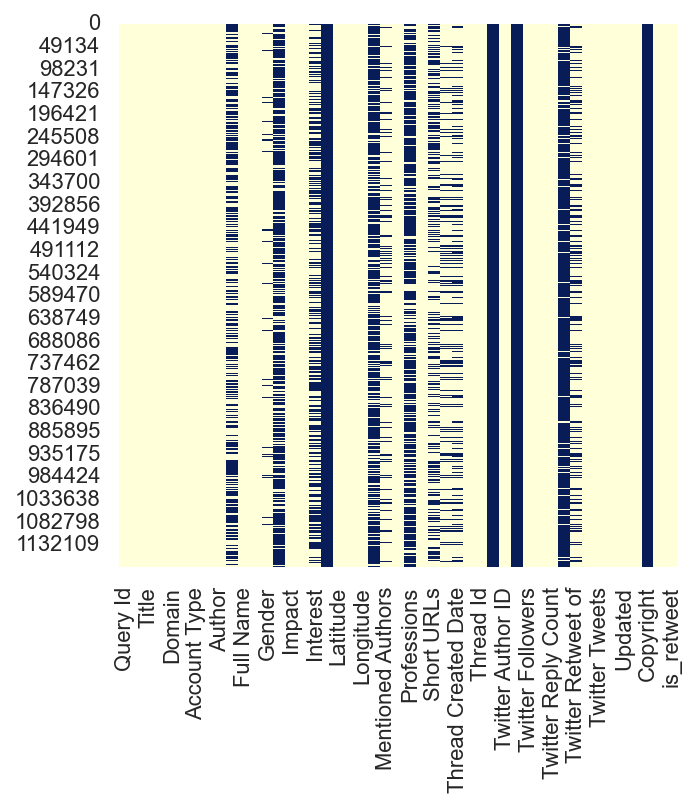

There are  0  empty observations needed to be removed.
 
There are  0  duplicated values in the data set.
CPU times: total: 6min 59s
Wall time: 6min 59s


In [139]:
%%time
tw_pitt = clean_df( tw_pitt, nonempty_features = ['Date', 'Full Text'] )

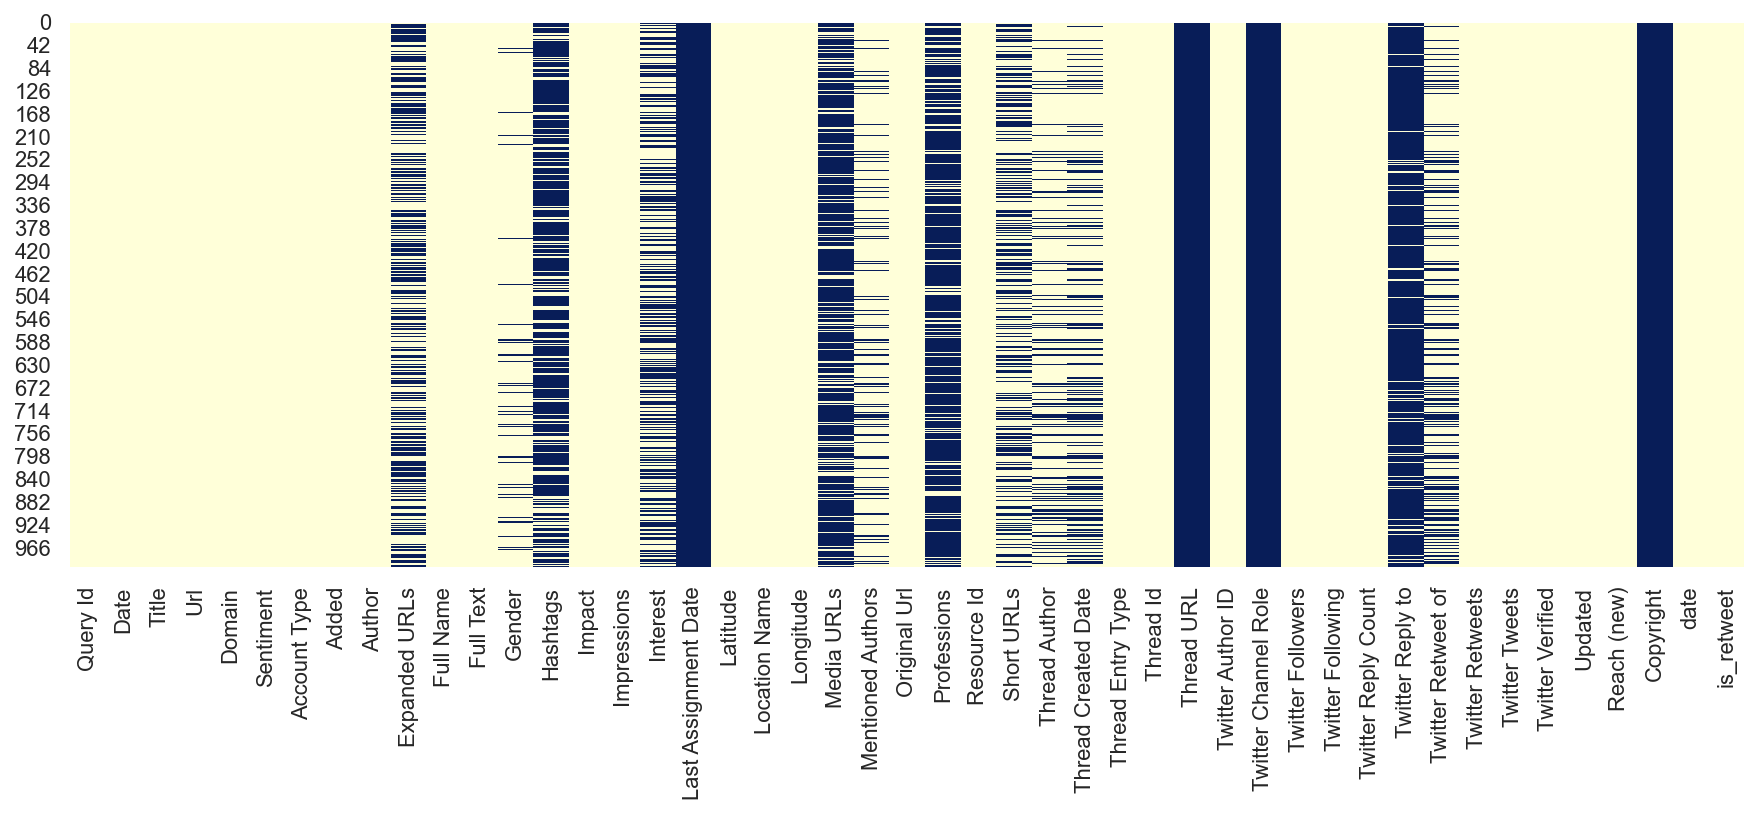

In [144]:
plt.figure(figsize = (15,5))
sns.heatmap(tw_pitt.head(1000).isnull(), cbar = False, cmap = 'YlGnBu')
plt.show()  # few data without summary

In [154]:
# drop useless columns
cols_to_be_dropped = ['Expanded URLs','Hashtags','Interest','Last Assignment Date','Media URLs',
                      'Professions','Short URLs', 'Thread Author', 'Thread Created Date','Thread URL',
                      'Twitter Channel Role','Twitter Reply to', 'Twitter Retweet of','Copyright','Mentioned Authors'
                      'Gender']
tw_pitt.drop(columns=cols_to_be_dropped, inplace=True)

<AxesSubplot:>

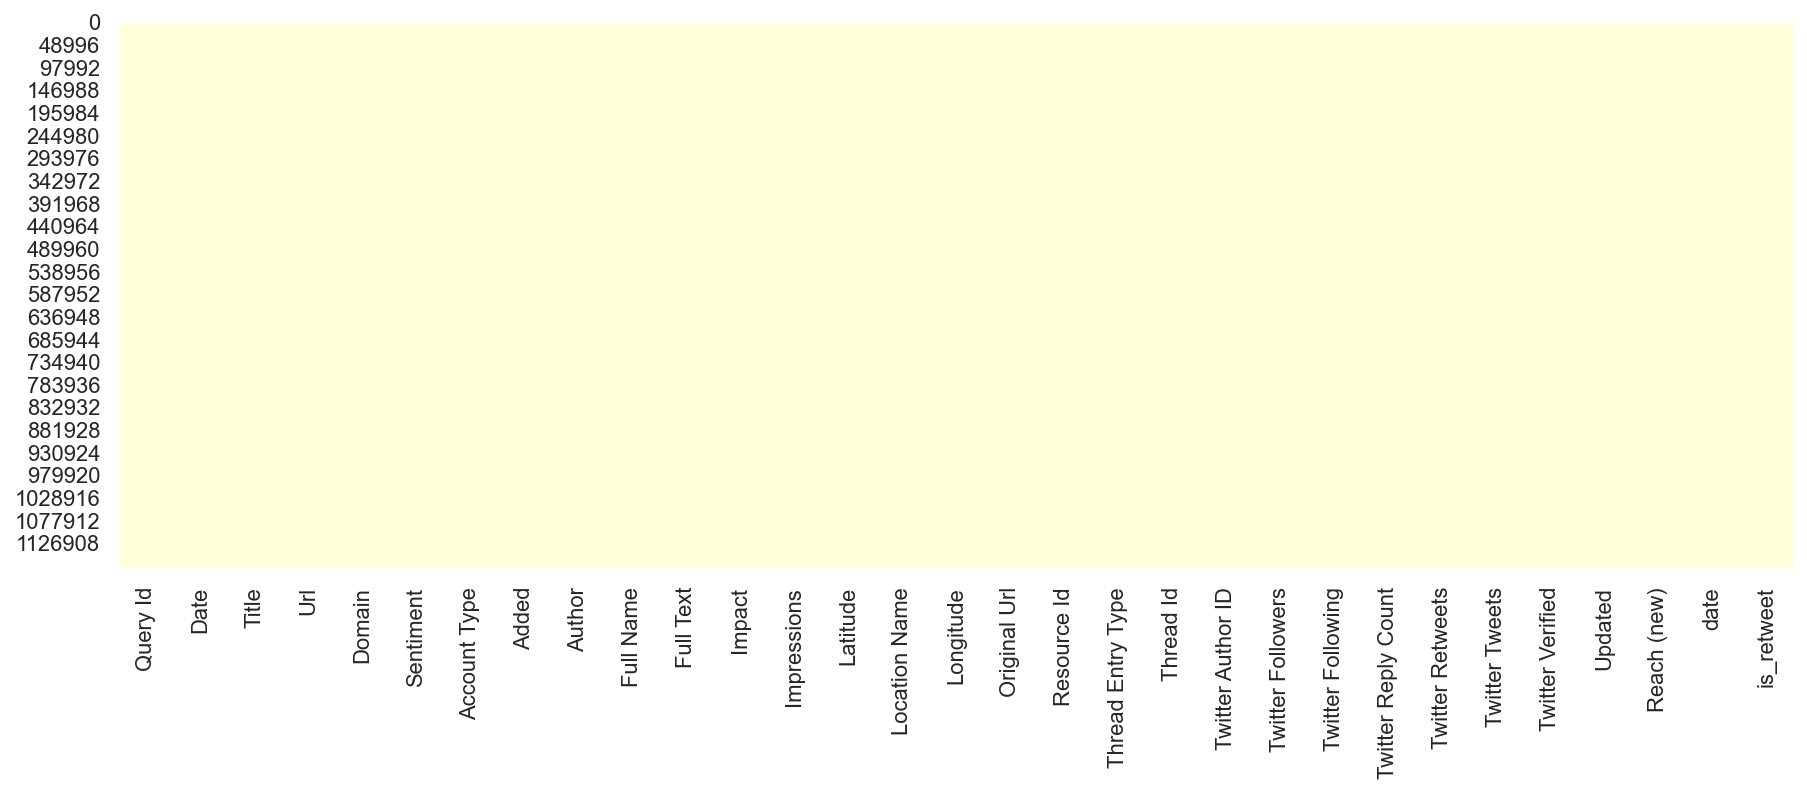

In [156]:
plt.figure(figsize = (15,5))
sns.heatmap(tw_pitt.isnull(), cbar = False, cmap = 'YlGnBu')

# Cleaning - Text

In [37]:
tw_pitt.Title.tolist()[:10]

["RT @stephaniemlee New story, from me: An NIH panel said there's no good data to show that convalescent plasma treats the coronavirus, contradicting Trump. https://t.co/hEsPaA33ZK",
 'RT @Leigh4USA Pelosi no mask 😷 in a hair salon!\n👇🙄\n\nRT Pass the stimulus Bill!\n@Leigh4USA 🇺🇸 We paid for that👇\nhttps://t.co/PTIFZwp914',
 'RT @Liz_Wheeler So Pelosi gets a blowout in a hair salon (without a mask), but YOU are not allowed. That’s all you need to know about the politicians wrecking our economy in the name of COVID-19.',
 "Some news from Pitt's covid-19 data dashboard: https://t.co/8YvyjqnIQq",
 'RT @ryanstruyk FAUCI: “The numbers that you’ve been hearing, the 180,000+ deaths, are real deaths from COVID-19. Let there not be any confusion about that. It’s not 9,000 deaths from COVID-19. It’s 180,000+ deaths.”',
 '@NYGovCuomo You literally caused the high COVID statistics in your city.  I mean, they were the highest in the country, and most places in the world.  Sit. This. One. Out. Bro.

In [38]:
tw_pitt['Full Text'].tolist()[:10]

["RT @stephaniemlee New story, from me: An NIH panel said there's no good data to show that convalescent plasma treats the coronavirus, contradicting Trump. https://t.co/hEsPaA33ZK",
 'RT @Leigh4USA Pelosi no mask 😷 in a hair salon! 👇🙄 RT Pass the stimulus Bill! @Leigh4USA 🇺🇸 We paid for that👇 https://t.co/PTIFZwp914',
 'RT @Liz_Wheeler So Pelosi gets a blowout in a hair salon (without a mask), but YOU are not allowed. That’s all you need to know about the politicians wrecking our economy in the name of COVID-19.',
 "Some news from Pitt's covid-19 data dashboard: https://t.co/8YvyjqnIQq",
 'RT @ryanstruyk FAUCI: “The numbers that you’ve been hearing, the 180,000+ deaths, are real deaths from COVID-19. Let there not be any confusion about that. It’s not 9,000 deaths from COVID-19. It’s 180,000+ deaths.”',
 '@NYGovCuomo You literally caused the high COVID statistics in your city. I mean, they were the highest in the country, and most places in the world. Sit. This. One. Out. Bro... and y

In [247]:
import re
from tqdm import tqdm

from nltk.corpus import stopwords as stpw
from nltk.stem.wordnet import WordNetLemmatizer
from nltk import word_tokenize, pos_tag # nltk.download('averaged_perceptron_tagger')
 
# lemmatization
lemma = WordNetLemmatizer() 

# stop words
def update_stopwords():
    from nltk.corpus import stopwords as stpw
    stopwords = []
    path = "D:/Python_project/Infodemics/Media_Collection/Cleaning/"
    with open(path+"stopwords_en.txt", "r") as f1:
        for stopword in f1.readlines():
            stopwords.append(stopword.strip('\n'))
        
    with open(path+"extra_stopwords_en.txt", "r") as f2:
        for stopword in f2.readlines():
            stopwords.append(stopword.strip('\n'))

    stopwords.extend(stpw.words('english'))
    stopwords = set(stopwords)
    return stopwords
stopwords = update_stopwords()

In [29]:
# Cleaning functions
def replace_words(temp):
    # temp = tweet.lower()
    temp = temp.replace('covid 19' , 'covid19')
    temp = temp.replace('covid-19' , 'covid19')
    temp = temp.replace('hong kong' , 'hongkong')
    temp = temp.replace('wu han' , 'wuhan') 
    temp = temp.replace('tests' , 'test')
    temp = temp.replace('tested' , 'test')
    temp = temp.replace('testing' , 'test')
    temp = temp.replace('reopening' , 'reopen')
    temp = temp.replace('ppl' , 'people')
    temp = temp.replace('rt ' , '')
    return temp
def filter_words(temp):
    # temp = tweet.lower()  
    # fist filter
    temp = [w for w in temp.split(' ') if not w in stopwords]
    temp = " ".join(word for word in temp)
    # to avoid removing contractions in english
    temp = re.sub("'", "", temp) 
    # Removing hashtags and mentions
    temp = re.sub("@[A-Za-z0-9_]+","", temp)
    temp = re.sub("#[A-Za-z0-9_]+","", temp)
    # Removing links
    temp = re.sub(r"http\S+", "", temp)
    temp = re.sub(r"www.\S+", "", temp)
    # Removing punctuations
    temp = re.sub('[()!?]', ' ', temp)
    temp = re.sub('\[.*?\]',' ', temp)
    # Filtering non-alphanumeric characters
    temp = re.sub("[^a-z0-9]"," ", temp)
    return temp
def convert_postag(word2pos):
    # word2pos = ('eating', 'VBG')
    word = word2pos[0]
    tag = word2pos[1]
    
    if tag.startswith('J'):
        tag = 'a'
    elif tag.startswith('V'):
        tag = 'v'
    elif tag.startswith('N'):
        tag = 'n'
    elif tag.startswith('R'):
        tag = 'r'
    else:
        tag = 'skip'
        
    return (word,tag)
def filter_useful_pos(temp):
    wordlst = word_tokenize(temp)
    word2pos_lst = pos_tag(wordlst)
    word2pos_lst = [convert_postag(word2pos) for word2pos in word2pos_lst]
    word2pos_lst = [word2pos for word2pos in word2pos_lst if not word2pos[1] == 'skip']
    return word2pos_lst
def clean_tweet(tweet):
    # print(tweet)
    temp = tweet.lower()
    temp = filter_words(temp)
    temp = replace_words(temp)
    
    word2pos_lst = filter_useful_pos(temp)
    temp = [WordNetLemmatizer().lemmatize(word2pos[0],word2pos[1]) for word2pos in word2pos_lst ]
    # second filter
    temp = [w for w in temp if not w in stopwords]
    temp = " ".join(word for word in temp)
    # print(temp)
    return temp

In [112]:
# Notes
'''
                            WordNetLemmatizer().lemmatize( word , pos: str = "n" )

                                        "n" for nouns (default),
                                        "v" for verbs, 
                                        "a" for adjectives, 
                                        "r" for adverbs 
                                        "s" for satellite adjectives.
'''
        
WordNetLemmatizer().lemmatize('eating','v') # eat
WordNetLemmatizer().lemmatize('eating')     # eating


'''
                            # Get pos 词性

                            from nltk import word_tokenize, pos_tag
                            # nltk.download('averaged_perceptron_tagger')

                            pos_tag(wordslst) 

'''

pos_tag(["eat"])

[('eat', 'NN')]

In [177]:
%%time
cleaned_tweets = tw_pitt['Full Text'].apply(lambda x: clean_tweet(x))
tw_pitt['cleaned_text'] = cleaned_tweets

CPU times: total: 25min 28s
Wall time: 25min 28s


In [244]:
# Furter clean
def filter_words2(temp):
    # temp = tweet.lower()  
    # fist filter
    temp = [w for w in temp.split(' ') if not w in stopwords]
    temp = [w for w in temp if len(w)>2]
    
    temp = " ".join(word for word in temp)
    return temp

In [208]:
%%time
cleaned_tweets = tw_pitt['cleaned_text'].apply(lambda x: filter_words2(x))
tw_pitt['cleaned_text'] = cleaned_tweets
print('Total',(tw_pitt['cleaned_text'].apply(len)==0).sum(),'empty texts')

Total 5410 empty texts
CPU times: total: 3.58 s
Wall time: 3.59 s


In [209]:
drop_obs = tw_pitt[(tw_pitt['cleaned_text'].apply(len)==0)].index
tw_pitt = tw_pitt.drop(drop_obs).reset_index()
print('Total',(tw_pitt['cleaned_text'].apply(len)==0).sum(),'empty texts')

Total 0 empty texts


In [219]:
tw_pitt.to_csv('tw_pitt_cleaned.csv', index=False)
tw_pitt[['Date', 'cleaned_text','is_retweet']].to_csv('tw_pitt_cleaned_onlytext.csv', index=False)

# Filter by Word Count 

In [339]:
# Define word count function
def count_words(wordslst):
    df = pd.DataFrame( {'Word': wordslst, 'Count':np.zeros(len(wordslst))} )
    wordcounts = df.groupby('Word').agg({'Count':np.size}).sort_values(by = 'Count', ascending = False)
    wordcounts['Prop%'] = (wordcounts.Count/len(wordslst))*100
    wordcounts = wordcounts.reset_index()
    
    # sort_values(by=‘ColumnName’, axis=0 , ascending = True , inplace = False, na_position = ‘last’ )
    # the column name of agg must be pre-determined
    # df = df.reset_index() can maintain the original index as a column and add a new index starting from 0

    return wordcounts
def checkWords(word, wordcounts):
    # wordcounts is the df defined from above using count_words( wordslst )     
    return wordcounts[ wordcounts['Words'] == word ]
def display_wordcounts(Type, rank, wordcounts, display=True):
    n = wordcounts.shape[0]
    
    if rank==-1:
        temp = wordcounts
        rank = wordcounts.shape[0]
    elif Type == 'top':
        temp = wordcounts.iloc[:rank,:]
    elif Type == 'bottom':
        temp = wordcounts.iloc[n-rank:,:]
        
    lst = [(temp.iloc[i,0],temp.iloc[i,1],temp.iloc[i,2]) for i in range(rank)]
    
    if display:     
        for i in range(rank):
            print("%-20s\t%-10d\t%.7f"%(lst[i][0],lst[i][1],lst[i][2]))     
    return lst

In [369]:
tw_pitt = pd.read_csv('tw_pitt_cleaned_onlytext.csv')
tw_pitt = tw_pitt.fillna('')
all_words = ' '.join(list(tw_pitt.cleaned_text)).split()
wordcounts = count_words(all_words)
display(wordcounts)

,Word,Count,Prop%
0,mask,200650,2.228790
1,trump,142234,1.579914
2,test,117723,1.307649
3,case,94871,1.053813
4,death,69051,0.767008
...,...,...,...
3018,slip,501,0.005565
3019,prospect,500,0.005554
3020,sweep,500,0.005554
3021,swing,500,0.005554


## Full Text Word Count

In [370]:
top_prop = 0.0041653
print(wordcounts[wordcounts['Prop%']>=top_prop]['Prop%'].sum())
print(wordcounts[wordcounts['Prop%']>=top_prop]['Count'].sum())
print()
top = display_wordcounts('top', -1, wordcounts[wordcounts['Prop%']>=top_prop])

100.00000000000001
9002643

mask                	200650    	2.2287899
trump               	142234    	1.5799138
test                	117723    	1.3076493
case                	94871     	1.0538128
death               	69051     	0.7670081
social              	68709     	0.7632092
health              	62643     	0.6958290
time                	61345     	0.6814110
work                	57770     	0.6417004
american            	51152     	0.5681887
stay                	50531     	0.5612907
die                 	50259     	0.5582694
president           	45406     	0.5043630
spread              	44545     	0.4947991
vaccine             	42000     	0.4665297
distancing          	41185     	0.4574768
positive            	38738     	0.4302959
news                	36213     	0.4022485
life                	35743     	0.3970279
public              	33573     	0.3729238
order               	33263     	0.3694804
break               	32814     	0.3644930
lockdown            	32478     	0.3607607
care  

In [282]:
bottom_prop = 0.0041653
print(wordcounts[wordcounts['Prop%']<bottom_prop]['Prop%'].sum())
print(wordcounts[wordcounts['Prop%']<bottom_prop]['Count'].sum())
print()
bottom = display_wordcounts('top', -1, wordcounts[wordcounts['Prop%']<bottom_prop])

15.69007002505114
1883412

greg                	499       	0.0041570
biological          	499       	0.0041570
apocalypse          	499       	0.0041570
bully               	499       	0.0041570
championship        	497       	0.0041403
tokyo               	497       	0.0041403
dive                	496       	0.0041320
salute              	496       	0.0041320
cnns                	496       	0.0041320
nevada              	496       	0.0041320
ache                	496       	0.0041320
hammer              	495       	0.0041237
spark               	495       	0.0041237
monger              	495       	0.0041237
prize               	495       	0.0041237
irony               	495       	0.0041237
simultaneously      	494       	0.0041153
insult              	494       	0.0041153
elephant            	493       	0.0041070
peddle              	493       	0.0041070
availability        	493       	0.0041070
abide               	493       	0.0041070
angela              	493       	0.0041070
exclude

everytime           	142       	0.0011830
efficiently         	142       	0.0011830
curated             	142       	0.0011830
dub                 	142       	0.0011830
replicate           	142       	0.0011830
transformation      	141       	0.0011746
folx                	141       	0.0011746
asked               	141       	0.0011746
perceive            	141       	0.0011746
convinced           	141       	0.0011746
irrelevant          	141       	0.0011746
rev                 	141       	0.0011746
flew                	141       	0.0011746
robin               	141       	0.0011746
concession          	141       	0.0011746
suburban            	141       	0.0011746
cripeopleed         	141       	0.0011746
attract             	141       	0.0011746
cellphone           	141       	0.0011746
sanjay              	141       	0.0011746
aaron               	141       	0.0011746
nyu                 	141       	0.0011746
collector           	141       	0.0011746
appropriation       	141       	0.

marie               	65        	0.0005415
incomprehensible    	65        	0.0005415
unilaterally        	65        	0.0005415
myers               	65        	0.0005415
url                 	65        	0.0005415
unintentional       	65        	0.0005415
hypoxia             	65        	0.0005415
ninth               	65        	0.0005415
ensue               	65        	0.0005415
ventura             	65        	0.0005415
rouhani             	65        	0.0005415
slipknot            	65        	0.0005415
enzyme              	65        	0.0005415
criminalize         	65        	0.0005415
meta                	65        	0.0005415
authentic           	65        	0.0005415
bodily              	65        	0.0005415
youtubed            	65        	0.0005415
suppocontinue       	65        	0.0005415
diaz                	65        	0.0005415
huability           	65        	0.0005415
fatty               	65        	0.0005415
spice               	65        	0.0005415
powerless           	65        	0.

discovered          	36        	0.0002999
sneaky              	36        	0.0002999
attribution         	36        	0.0002999
booed               	36        	0.0002999
unserious           	36        	0.0002999
comey               	36        	0.0002999
ventec              	36        	0.0002999
greensboro          	36        	0.0002999
drift               	36        	0.0002999
yous                	36        	0.0002999
catalogue           	36        	0.0002999
standardize         	36        	0.0002999
dramatize           	36        	0.0002999
describing          	36        	0.0002999
newman              	36        	0.0002999
brow                	36        	0.0002999
jailbreak           	36        	0.0002999
victorious          	36        	0.0002999
ranch               	36        	0.0002999
shim                	36        	0.0002999
mutha               	36        	0.0002999
socal               	36        	0.0002999
didier              	36        	0.0002999
constrain           	36        	0.

brutalized          	21        	0.0001749
stepped             	21        	0.0001749
reconfigured        	21        	0.0001749
taxed               	21        	0.0001749
leana               	21        	0.0001749
punt                	21        	0.0001749
hanging             	21        	0.0001749
thor                	21        	0.0001749
lam                 	21        	0.0001749
suppomandatory      	21        	0.0001749
chinatowns          	21        	0.0001749
gohmetelling        	21        	0.0001749
drilling            	21        	0.0001749
heagreat            	21        	0.0001749
morse               	21        	0.0001749
pasa                	21        	0.0001749
abandonment         	21        	0.0001749
perished            	21        	0.0001749
dropped             	21        	0.0001749
fax                 	21        	0.0001749
negotiable          	21        	0.0001749
tormund             	21        	0.0001749
dumbasses           	21        	0.0001749
admonish            	21        	0.

...

bv4                 	1         	0.0000083
burnette            	1         	0.0000083
burman              	1         	0.0000083
bude                	1         	0.0000083
bulkshit            	1         	0.0000083
bukhari             	1         	0.0000083
bukkie              	1         	0.0000083
buklshit            	1         	0.0000083
buks                	1         	0.0000083
bukunmi             	1         	0.0000083
bulas               	1         	0.0000083
bulbous             	1         	0.0000083
bulby               	1         	0.0000083
bulgy               	1         	0.0000083
bulimia             	1         	0.0000083
buliold             	1         	0.0000083
buljic              	1         	0.0000083
bulking             	1         	0.0000083
bullahit            	1         	0.0000083
bukele              	1         	0.0000083
bulleted            	1         	0.0000083
bulletproofing      	1         	0.0000083
bullfighter         	1         	0.0000083
bullfighting        	1         	0.

mcmask              	1         	0.0000083
mcmccain            	1         	0.0000083
mcmichaels          	1         	0.0000083
megalodon           	1         	0.0000083
megalomanic         	1         	0.0000083
megamaniacal        	1         	0.0000083
mesoblast           	1         	0.0000083
mershmellow         	1         	0.0000083
merssars            	1         	0.0000083
merv13              	1         	0.0000083
mervosh             	1         	0.0000083
merwins             	1         	0.0000083
meryls              	1         	0.0000083
mes                 	1         	0.0000083
mesaage             	1         	0.0000083
mesaglio            	1         	0.0000083
mesententic         	1         	0.0000083
mesenteric          	1         	0.0000083
mesita              	1         	0.0000083
meso                	1         	0.0000083
mesopotamia         	1         	0.0000083
merseyside          	1         	0.0000083
mesozoic            	1         	0.0000083
mesquite            	1         	0.

pghlgbtq            	1         	0.0000083
pghpd               	1         	0.0000083
pghsews             	1         	0.0000083
pgsf                	1         	0.0000083
peyote              	1         	0.0000083
peyer               	1         	0.0000083
pewsistent          	1         	0.0000083
peverse             	1         	0.0000083
petrosino           	1         	0.0000083
petrostates         	1         	0.0000083
petrovic            	1         	0.0000083
petrovskys          	1         	0.0000083
petrucci            	1         	0.0000083
petry               	1         	0.0000083
petsma              	1         	0.0000083
petsmacharities     	1         	0.0000083
petsmaemployees     	1         	0.0000083
petsmamask          	1         	0.0000083
petsonk             	1         	0.0000083
petss               	1         	0.0000083
pettali             	1         	0.0000083
pettengill          	1         	0.0000083
petticoat           	1         	0.0000083
pettifog            	1         	0.

hcquinine           	1         	0.0000083
hcu                 	1         	0.0000083
hcworkers           	1         	0.0000083
hd28                	1         	0.0000083
hdk                 	1         	0.0000083
hdms                	1         	0.0000083
hdr                 	1         	0.0000083
hdroxy              	1         	0.0000083
hdrp                	1         	0.0000083
hdvitc              	1         	0.0000083
heaailment          	1         	0.0000083
hea2                	1         	0.0000083
hea647              	1         	0.0000083
hea70               	1         	0.0000083
heaabnormalities    	1         	0.0000083
heaabnormality      	1         	0.0000083
heaabyssal          	1         	0.0000083
heaache             	1         	0.0000083
heaached            	1         	0.0000083
heaaction           	1         	0.0000083
heaactivity         	1         	0.0000083
heaaffected         	1         	0.0000083
heaaflutter         	1         	0.0000083
heaagain            	1         	0.

kentu               	1         	0.0000083
kentuckians         	1         	0.0000083
kentwired           	1         	0.0000083
kenward             	1         	0.0000083
kenwood             	1         	0.0000083
kenzie1055          	1         	0.0000083
keolis              	1         	0.0000083
keon                	1         	0.0000083
kepeopleer          	1         	0.0000083
kendzior            	1         	0.0000083
kendel              	1         	0.0000083
kendal              	1         	0.0000083
kenardo             	1         	0.0000083
keisler             	1         	0.0000083
keita               	1         	0.0000083
keiths              	1         	0.0000083
kejuane             	1         	0.0000083
keke                	1         	0.0000083
kekst               	1         	0.0000083
kel                 	1         	0.0000083
keldibekova         	1         	0.0000083
kelenic             	1         	0.0000083
kelkyanne           	1         	0.0000083
kell                	1         	0.

## Update Stopwords and Filtering

In [283]:
bottom_words= [x[0] for x in bottom] 

In [365]:
# add new stopwords
def add_stopwords(wordlst):
    path = "D:/Python_project/Infodemics/Media_Collection/Cleaning/extra_stopwords_en.txt"   
    with open(path, 'a') as f:
        for word in wordlst:
            f.write('\n'+word)
    f.close()
    return
def update_stopwords():
    from nltk.corpus import stopwords as stpw
    stopwords = []
    path = "D:/Python_project/Infodemics/Media_Collection/Cleaning/"
    with open(path+"stopwords_en.txt", "r") as f1:
        for stopword in f1.readlines():
            stopwords.append(stopword.strip('\n'))
        
    with open(path+"extra_stopwords_en.txt", "r") as f2:
        for stopword in f2.readlines():
            stopwords.append(stopword.strip('\n'))

    stopwords.extend(stpw.words('english'))
    stopwords = set(stopwords)
    return stopwords

In [ ]:
add_stopwords(bottom_words)

In [380]:
stopwords = update_stopwords()

In [368]:
def filter_words2(temp):
    # temp = tweet.lower()  
    # fist filter
    temp = [w for w in temp.split(' ') if not w in stopwords]
    temp = [w for w in temp if len(w)>2]
    
    temp = " ".join(word for word in temp)
    return temp

In [371]:
tw_pitt['cleaned_text'] = tw_pitt.cleaned_text.apply(lambda x: filter_words2(x))

In [372]:
tw_pitt.to_csv('tw_pitt_cleaned_onlytext.csv', index=False)

# Select by Verb & None

In [373]:
tw_pitt = pd.read_csv('tw_pitt_cleaned_onlytext.csv')
tw_pitt = tw_pitt.fillna('')

In [347]:
from nltk.stem.wordnet import WordNetLemmatizer
from nltk import word_tokenize, pos_tag 

def filter_noneNVtag(word2pos):
    # word2pos = ('eating', 'VBG')
    word = word2pos[0]
    tag = word2pos[1]
    
    if tag.startswith('V') or tag.startswith('N'):
        return (word,tag)
    else:
        tag = 'skip'    
    return (word,tag)
def none_and_verb(temp):
    wordlst = word_tokenize(temp)
    word2pos_lst = pos_tag(wordlst)
    word2pos_lst = [filter_noneNVtag(word2pos) for word2pos in word2pos_lst]
    word2pos_lst = [word2pos for word2pos in word2pos_lst if not word2pos[1] == 'skip']
    wordlst = [word2pos[0] for word2pos in word2pos_lst ]
    temp = " ".join(wordlst)
    return temp

def filter_noneNtag(word2pos):
    # word2pos = ('eating', 'VBG')
    word = word2pos[0]
    tag = word2pos[1]
    
    if tag.startswith('N'):
        return (word,tag)
    else:
        tag = 'skip'    
    return (word,tag)
def none(temp):
    wordlst = word_tokenize(temp)
    word2pos_lst = pos_tag(wordlst)
    word2pos_lst = [filter_noneNtag(word2pos) for word2pos in word2pos_lst]
    word2pos_lst = [word2pos for word2pos in word2pos_lst if not word2pos[1] == 'skip']
    wordlst = [word2pos[0] for word2pos in word2pos_lst ]
    temp = " ".join(wordlst)
    return temp

In [376]:
tw_pitt

,Date,cleaned_text,is_retweet,cleaned_text_verb_noun,cleaned_text_noun
0,2020-01-01,cruise deserve learn mask work hard feeling power,1,cruise deserve learn mask work hard feeling power,cruise deserve learn mask work hard feeling power
1,2020-01-01,trump pose mask killer navy prisoner,1,trump pose mask killer navy prisoner,trump pose mask killer navy prisoner
2,2020-01-01,mother mask burn,0,mother mask burn,mother mask burn
3,2020-01-01,mask fit glove extra extra mask,1,mask fit glove extra extra mask,mask fit glove extra extra mask
4,2020-01-01,failure mask,0,failure mask,failure mask
...,...,...,...,...,...
1170482,2020-09-01,pelosi mask hair salon stimulus pay,1,pelosi mask hair salon stimulus pay,pelosi mask hair salon stimulus pay
1170483,2020-09-01,lady heard mask wrong message level power mask,1,lady heard mask wrong message level power mask,lady heard mask wrong message level power mask
1170484,2020-09-01,german study patient lead personal decade,1,german study patient lead personal decade,german study patient lead personal decade
1170485,2020-09-01,operate law party leader talk blow,1,operate law party leader talk blow,operate law party leader talk blow


In [377]:
# test function
temp = tw_pitt.iloc[0,1]
print(temp)
print(none_and_verb(temp))
print(none(temp))

cruise deserve learn mask work hard feeling power
cruise deserve learn mask work feeling power
cruise deserve learn mask work power


In [381]:
%%time
cleaned_verb_noun = tw_pitt['cleaned_text'].apply(lambda x: none_and_verb(x))
tw_pitt['cleaned_text_verb_noun'] = cleaned_verb_noun

CPU times: total: 27min 55s
Wall time: 27min 56s


In [382]:
%%time
cleaned_noun = tw_pitt['cleaned_text'].apply(lambda x: none(x))
tw_pitt['cleaned_text_noun'] = cleaned_noun

CPU times: total: 27min 4s
Wall time: 27min 5s


In [375]:
# Extra Filter
tw_pitt['cleaned_text'] = tw_pitt.cleaned_text.apply(lambda x: filter_words2(x))
tw_pitt['cleaned_text_verb_noun'] = tw_pitt.cleaned_text.apply(lambda x: filter_words2(x))
tw_pitt['cleaned_text_noun'] = tw_pitt.cleaned_text.apply(lambda x: filter_words2(x))
tw_pitt.to_csv('tw_pitt_cleaned_onlytext.csv', index=False)

In [383]:
original_tw_pitt = tw_pitt[tw_pitt.is_retweet==0]
original_tw_pitt = original_tw_pitt.sort_index()

In [384]:
original_tw_pitt

,Date,cleaned_text,is_retweet,cleaned_text_verb_noun,cleaned_text_noun
2,2020-01-01,mother mask burn,0,mother mask burn,mother mask burn
4,2020-01-01,failure mask,0,failure mask,failure mask
7,2020-01-01,happy celebrate officially delete mask night f...,0,celebrate mask night fell choice,celebrate mask night choice
9,2020-01-01,mask slip dark normal behavior,0,mask slip dark behavior,mask slip dark behavior
15,2020-01-01,lockdown,0,lockdown,lockdown
...,...,...,...,...,...
1170453,2020-09-01,joe continue democrat,0,joe continue democrat,joe democrat
1170462,2020-09-01,neighbor scream street problem friend block ho...,0,neighbor scream street problem friend block ho...,neighbor scream street problem friend block ho...
1170465,2020-09-01,trump white house penny deborah birx warn coll...,0,house penny deborah birx warn college infected...,house penny deborah birx college student
1170478,2020-09-01,literally statistic place sit bro walk mask,0,place sit bro walk mask,place sit bro walk mask


In [385]:
tw_pitt.to_csv('tw_pitt_cleaned_onlytext.csv', index=False)
original_tw_pitt.to_csv('tw_pitt_original_cleaned.csv', index=False)

# Tweets By Day

In [386]:
tw_pitt = pd.read_csv('tw_pitt_cleaned_onlytext.csv')
tw_pitt = tw_pitt.fillna('')
original_tw_pitt = pd.read_csv('tw_pitt_original_cleaned.csv')
original_tw_pitt = original_tw_pitt.fillna('')

In [387]:
# Data Type 
tw_pitt_text2day  = tw_pitt[['Date','cleaned_text']]           # All text
tw_pitt_VN2day    = tw_pitt[['Date','cleaned_text_verb_noun']] # All verb and none
tw_pitt_N2day     = tw_pitt[['Date','cleaned_text_noun']]      # All verb and none

original_text2day = original_tw_pitt[['Date','cleaned_text']]            # original text
original_VN2day   = original_tw_pitt[['Date','cleaned_text_verb_noun']]  # original verb and none
original_N2day    = original_tw_pitt[['Date','cleaned_text_noun']]       # original verb and none

In [388]:
def sumstr(df):
    return ' '.join(list(df.iloc[:,1]))

In [389]:
tw_pitt_text2day  = tw_pitt_text2day.groupby('Date').apply(lambda df: sumstr(df))
tw_pitt_VN2day    = tw_pitt_VN2day.groupby('Date').apply(lambda df: sumstr(df))
tw_pitt_N2day     = tw_pitt_N2day.groupby('Date').apply(lambda df: sumstr(df))

original_text2day = original_text2day.groupby('Date').apply(lambda df: sumstr(df))
original_VN2day   = original_VN2day.groupby('Date').apply(lambda df: sumstr(df))
original_N2day    = original_N2day.groupby('Date').apply(lambda df: sumstr(df))

In [390]:
tw_pitt_text2day  = pd.DataFrame(tw_pitt_text2day,columns=['Content'])
tw_pitt_VN2day    = pd.DataFrame(tw_pitt_VN2day,columns=['Content'])
tw_pitt_N2day     = pd.DataFrame(tw_pitt_N2day ,columns=['Content'])

original_text2day = pd.DataFrame(original_text2day,columns=['Content'])
original_VN2day   = pd.DataFrame(original_VN2day,columns=['Content'])
original_N2day    = pd.DataFrame(original_N2day,columns=['Content'])

In [391]:
tw_pitt_text2day.to_csv('Doc1_text2day.csv', index=True)
tw_pitt_VN2day.to_csv('Doc2_VN2day.csv', index=True)
tw_pitt_N2day.to_csv('Doc3_N2day.csv', index=True)

original_text2day.to_csv('Doc4_original_text2day.csv', index=True)
original_VN2day.to_csv('Doc5_original_VN2day.csv', index=True)
original_N2day.to_csv('Doc6_original_N2day.csv', index=True)